In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import accuracy_score, mean_squared_error
from sklearn.compose import ColumnTransformer
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from xgboost import XGBRegressor

In [3]:
conda install xgboost

Retrieving notices: done
Channels:
 - defaults
Platform: osx-64
Solving environment: done

## Package Plan ##

  environment location: /Users/fmtetteroo/opt/anaconda3

  added / updated specs:
    - xgboost


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    certifi-2025.4.26          |  py312hecd8cb5_0         157 KB
    py-xgboost-2.1.1           |  py312hecd8cb5_0         365 KB
    scipy-1.15.2               |  py312hff9f4a3_1        23.1 MB
    xgboost-2.1.1              |  py312hecd8cb5_0          12 KB
    ------------------------------------------------------------
                                           Total:        23.7 MB

The following NEW packages will be INSTALLED:

  _py-xgboost-mutex  pkgs/main/osx-64::_py-xgboost-mutex-2.0-cpu_0 
  libxgboost         pkgs/main/osx-64::libxgboost-2.1.1-hab2016f_0 
  py-xgboost         pkgs/main/osx-64::py-xgboost-2.1.1-py312hecd8cb5_0 


In [6]:
data = pd.read_csv("final_offshore_data_2017_2025.csv")
data["date"] = data['full_datetime'].str.rsplit('-', n=1).str[0]
data[['date', 'hour']] = data['correct_days'].str.rsplit('-', n=1, expand=True)
data['hour'] = data['hour'].astype(int) - 1
data['datetime'] = pd.to_datetime(data['date']) + pd.to_timedelta(data['hour'], unit='H')
data = data[data["date"] < "2025-01-01"]

data['month'] = data['datetime'].dt.to_period('M').astype(str)

start_date = pd.Timestamp('2017-01-01')
data['week_number'] = ((data['datetime'] - start_date).dt.days // 7) + 1

# Set 'datetime' as index for the dataset
data.set_index('datetime', inplace=True)

data["max_capacity"] = data["capacity"] / data["percentage"]
data["log_volume"] = np.log1p(data["volume"])
data["ratio_VC"] = data["volume"] / data["max_capacity"]


/var/folders/19/l03rx7hx7313wlqw4t3dy1wm0000gn/T/ipykernel_97439/1277146375.py:5: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  data['datetime'] = pd.to_datetime(data['date']) + pd.to_timedelta(data['hour'], unit='H')


In [8]:
# Creating lag features for time-series data

def create_lag_features(data, lag_steps=1):
    for i in range(1, lag_steps + 1):
        data[f'lag_{i}'] = data['volume'].shift(i)

    return data

# Applying lag feature creation to the dataset

lagged_data = create_lag_features(data, lag_steps=1)

In [10]:
# Differencing technique for handling non-stationary data

data['stationary_volume'] = data['volume'].diff()

In [12]:
data['rolling_mean_3'] = data['volume'].rolling(window=3).mean()

In [14]:
data.head()

,year_mon_day,hour,wind_dir_avg_10,wind_speed_h_avg,wind_speed_avg_10,air_pressure,humidity,full_datetime,capacity,volume,...,correct_days,date,month,week_number,max_capacity,log_volume,ratio_VC,lag_1,stationary_volume,rolling_mean_3
datetime,,,,,,,,,,,,,,,,,,,,,
2017-01-01 00:00:00,20170101,0,213.586816,85.714286,86.428571,10206.75,95.714286,2017-01-01-01,873501,873501,...,2017-01-01-01,2017-01-01,2017-01,1,861300.638701,13.680266,1.014165,NaN,NaN,NaN
2017-01-01 01:00:00,20170101,1,210.905296,87.142857,90.714286,10199.75,96.142857,2017-01-01-02,883749,883749,...,2017-01-01-02,2017-01-01,2017-01,1,861299.242185,13.691929,1.026065,873501.0,10248.0,NaN
2017-01-01 02:00:00,20170101,2,208.585001,89.285714,87.857143,10191.50,96.000000,2017-01-01-03,872500,872500,...,2017-01-01-03,2017-01-01,2017-01,1,861299.705697,13.679119,1.013004,883749.0,-11249.0,876583.333333
2017-01-01 03:00:00,20170101,3,209.977979,90.000000,90.000000,10182.25,96.142857,2017-01-01-04,889750,889750,...,2017-01-01-04,2017-01-01,2017-01,1,861300.397937,13.698697,1.033031,872500.0,17250.0,881999.666667
2017-01-01 04:00:00,20170101,4,208.541568,89.285714,87.142857,10176.25,95.571429,2017-01-01-05,893251,893251,...,2017-01-01-05,2017-01-01,2017-01,1,861301.078959,13.702624,1.037095,889750.0,3501.0,885167.000000


In [16]:
len(data)

70128

In [18]:
data = data.dropna()

In [20]:
X = data.drop(["volume", "capacity",  #capacity & volume are the same
                    "emission", "emissionfactor", "log_volume", 
               "max_capacity", "stationary_volume"], #are always 0 and can be ignored
                      axis=1)

# our target variable
y = data["volume"]
y_log = data["log_volume"]
X_train = X[X["date"] < "2024-12-25"]
X_test = X[X["date"] >= "2024-12-25"]

# Label
y_train = y[:X_train.shape[0]] #list slice: from beginning to end of X-train
y_test = y[X_train.shape[0]:] #list slice: from end of X-train to the end of the data
y_train_log = y_log[:X_train.shape[0]]
y_test_log = y_log[X_train.shape[0]:]

In [22]:
print(X_train.shape)
print(y_train.shape)
print(y_test.shape)
print(X_test.shape)
print(y_train_log.shape)
print(y_test_log.shape)

(69498, 16)
(69498,)
(165,)
(165, 16)
(69498,)
(165,)


In [24]:
# subset dataframe to only contain the features we are interested in
numeric_features = ["wind_dir_avg_10", "wind_speed_h_avg", "wind_speed_avg_10", "air_pressure", "humidity", "percentage", "lag_1", "rolling_mean_3"]
X_train = X_train.loc[:, numeric_features]
X_test = X_test.loc[:, numeric_features]

# Define the preprocessor
preprocessor = ColumnTransformer([
    ("scaled_num", StandardScaler(), numeric_features)
])

# Transform the data with the scaler
X_train_norm = preprocessor.fit_transform(X_train)
X_test_norm = preprocessor.fit_transform(X_test)
X_train = pd.DataFrame(X_train_norm, columns=X_train.columns.values, index=X_train.index.values)
X_test = pd.DataFrame(X_test_norm, columns = X_test.columns.values, index=X_test.index.values)


In [26]:
print(X_train.shape)
print(y_train.shape)
print(y_test.shape)
print(X_test.shape)

(69498, 8)
(69498,)
(165,)
(165, 8)


In [91]:
param_grid = {
    'max_depth': [5, 7],  
    'min_child_weight': [1, 2, 3],  
    'learning_rate': [0.01, 0.05],  
    'n_estimators': [50, 100, 150],  
    'subsample': [0.75, 0.9],  
    'colsample_bytree': [0.75, 0.9]
}

XGB = XGBRegressor(random_state = 42)
cv_XGB = GridSearchCV(estimator=XGB, param_grid=param_grid, cv=5) #Here we perform a grid search with 5-fold cross validation
cv_XGB.fit(X_train, y_train) # Fit the model to the training set - this will perform the grid search and find the model with the best hyper-parameters

# Mean cross-validated score of the best_estimator
print("Mean cross-validated score of the best_estimator:", cv_XGB.best_score_)

# Print the best parameters
print("Best parameters:", cv_XGB.best_params_)

# Refit the model with the best parameters on the entire training set
XGB_model = cv_XGB.best_estimator_
XGB_pred = XGB_model.predict(X_test)

#Calculating the accuracy
print("Best XGB Classifier")
print("Test Set MSE: ", mean_squared_error(y_test, XGB_pred))


Mean cross-validated score of the best_estimator: 0.936859130859375
Best parameters: {'colsample_bytree': 0.9, 'learning_rate': 0.05, 'max_depth': 7, 'min_child_weight': 3, 'n_estimators': 150, 'subsample': 0.9}
Best XGB Classifier
Test Set MSE:  711607503020.0585


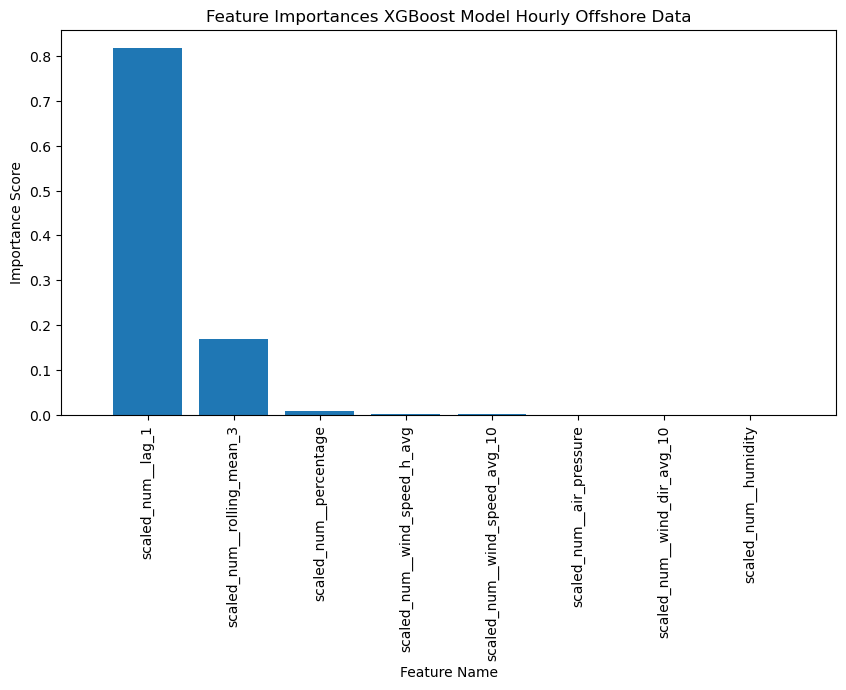

In [95]:
importances = XGB_model.feature_importances_

# Hint: We can get feature names from the preprocessor
feature_names = preprocessor.get_feature_names_out()

# Sort feature importances and feature names
indices = np.argsort(importances)[::-1]  # Sort in descending order
sorted_importances = importances[indices]
sorted_feature_names = feature_names[indices]  # Sort feature names accordingly

# Plot feature importances
plt.figure(figsize=(10, 5))
plt.title("Feature Importances XGBoost Model Hourly Offshore Data")
plt.bar(range(len(importances)), sorted_importances, align="center")
plt.xticks(range(len(importances)), sorted_feature_names, rotation=90, fontsize=10)  # Rotate for readability
plt.xlim([-1, len(importances)])
plt.xlabel("Feature Name")
plt.ylabel("Importance Score")
plt.show()

# Logged version

In [241]:
param_grid = {
    'max_depth': [5, 7],  
    'min_child_weight': [1, 2, 3],  
    'learning_rate': [0.01, 0.05],  
    'n_estimators': [50, 100, 150],  
    'subsample': [0.75, 0.9],  
    'colsample_bytree': [0.75, 0.9]
}

XGB = XGBRegressor(random_state = 42)
cv_XGB_log = GridSearchCV(estimator=XGB, param_grid=param_grid, cv=5) #Here we perform a grid search with 5-fold cross validation
cv_XGB_log.fit(X_train, y_train_log) # Fit the model to the training set - this will perform the grid search and find the model with the best hyper-parameters

# Mean cross-validated score of the best_estimator
print("Mean cross-validated score of the best_estimator:", cv_XGB_log.best_score_)

# Print the best parameters
print("Best parameters:", cv_XGB_log.best_params_)

# Refit the model with the best parameters on the entire training set
XGB_model_log = cv_XGB_log.best_estimator_
XGB_pred_log = XGB_model_log.predict(X_test)

#Calculating the accuracy
print("Best XGB Classifier")
print("Test Set MSE: ", mean_squared_error(y_test_log, XGB_pred_log))


Mean cross-validated score of the best_estimator: 0.967442203233521
Best parameters: {'colsample_bytree': 0.9, 'learning_rate': 0.05, 'max_depth': 7, 'min_child_weight': 1, 'n_estimators': 150, 'subsample': 0.9}
Best XGB Classifier
Test Set MSE:  1.6574703827627324


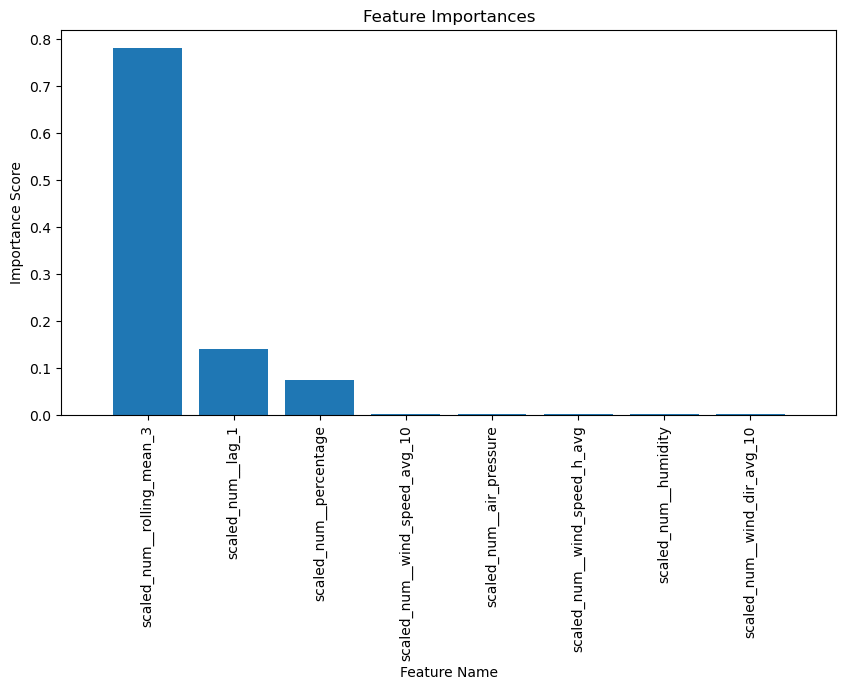

In [243]:
importances_log = XGB_model_log.feature_importances_

# Hint: We can get feature names from the preprocessor
feature_names = preprocessor.get_feature_names_out()

# Sort feature importances and feature names
indices = np.argsort(importances_log)[::-1]  # Sort in descending order
sorted_importances_log = importances_log[indices]
sorted_feature_names = feature_names[indices]  # Sort feature names accordingly

# Plot feature importances
plt.figure(figsize=(10, 5))
plt.title("Feature Importances")
plt.bar(range(len(importances_log)), sorted_importances_log, align="center")
plt.xticks(range(len(importances_log)), sorted_feature_names, rotation=90, fontsize=10)  # Rotate for readability
plt.xlim([-1, len(importances_log)])
plt.xlabel("Feature Name")
plt.ylabel("Importance Score")
plt.show()

In [28]:
x_axis_train = data["date"][:len(y_train_log)]
x_axis_test = data["date"][len(y_train_log):]
x_axis_train[0:5]
print(len(x_axis_train))
print(len(x_axis_test))

69498
165


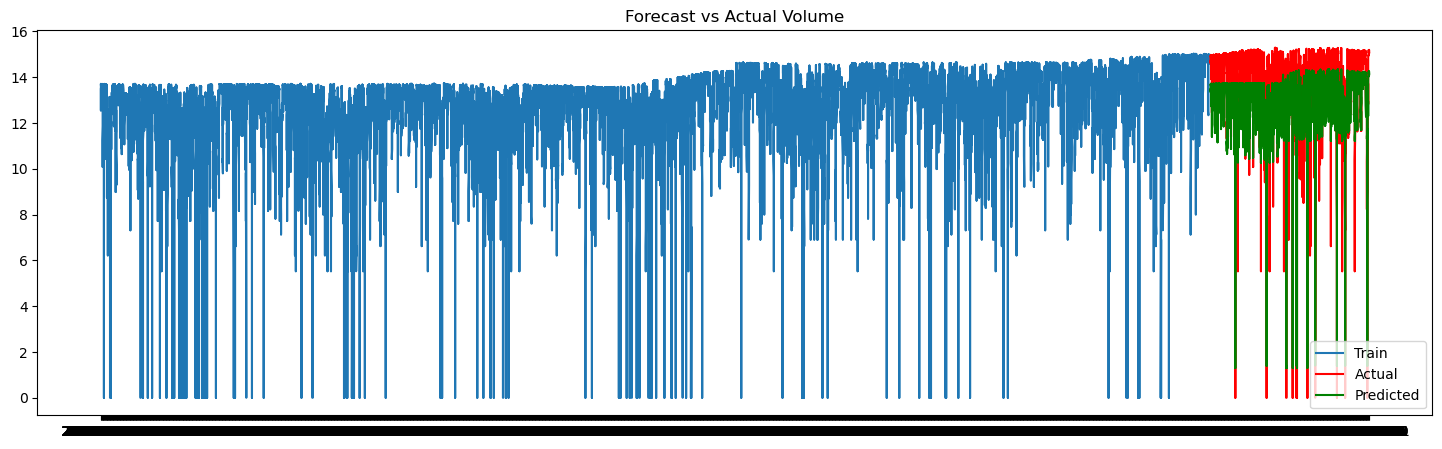

In [13]:
plt.figure(figsize=(18,5))
plt.plot(x_axis_train, y_train_log, label="Train")
plt.plot(x_axis_test, y_test_log, label="Actual", color='red')
plt.plot(x_axis_test, XGB_pred_log, label="Predicted", color='green')
plt.legend()
plt.title("Forecast vs Actual Volume")
plt.show()

# Monthly

In [30]:
# Convert hourly data to monthly data
db_monthly = data.groupby('month').mean(numeric_only=True)
# Split into train and test set
train_db = db_monthly[db_monthly.index <= '2024-06']
test_db = db_monthly[db_monthly.index > '2024-06']

X_month = db_monthly.drop(["volume", "capacity",  #capacity & volume are the same
                    "emission", "emissionfactor", "log_volume", "ratio_VC", "max_capacity", 
                           "stationary_volume"], #are always 0 and can be ignored
                      axis=1)

# our target variable
y_month_log = db_monthly["log_volume"]
y_month = db_monthly["volume"]

# Features
X_train_month = X_month[X_month.index <= '2024-06']
X_test_month = X_month[(X_month.index > '2024-06')]

# Label log
y_train_month_log = y_month_log[:X_train_month.shape[0]] #list slice: from beginning to end of X-train
y_test_month_log = y_month_log[X_train_month.shape[0]:] #list slice: from end of X-train to the end of the data

# Label
y_train_month = y_month[:X_train_month.shape[0]] #list slice: from beginning to end of X-train
y_test_month = y_month[X_train_month.shape[0]:] #list slice: from end of X-train to the end of the data


In [32]:
db_monthly.head()

,year_mon_day,hour,wind_dir_avg_10,wind_speed_h_avg,wind_speed_avg_10,air_pressure,humidity,capacity,volume,percentage,emission,emissionfactor,week_number,max_capacity,log_volume,ratio_VC,lag_1,stationary_volume,rolling_mean_3
month,,,,,,,,,,,,,,,,,,,
2017-01,2.017012e+07,11.523352,196.177050,61.469780,61.575026,10219.833906,85.249117,431171.729396,431171.729396,0.500606,0.0,0.0,2.736264,861302.847815,12.375440,0.500606,431761.013736,-589.284341,431746.592033
2017-02,2.017021e+07,11.500000,165.060252,75.307011,75.433870,10144.316964,87.309524,554432.208333,554432.208333,0.643716,0.0,0.0,6.928571,861299.976699,13.035314,0.643716,554483.919643,-51.711310,554446.593750
2017-03,2.017032e+07,11.500000,192.136378,64.632882,64.570503,10148.379704,82.628616,403941.505376,403941.505376,0.468991,0.0,0.0,11.129032,861298.459539,12.556493,0.468991,403882.701613,58.803763,403841.594086
2017-04,2.017042e+07,11.516129,252.841156,61.532583,61.610505,10203.872801,76.233103,386361.423754,386361.423754,0.448579,0.0,0.0,15.555718,861301.625732,12.394128,0.448579,385668.601173,692.822581,385707.583578
2017-05,2.017052e+07,11.534413,168.058414,56.660532,56.690538,10171.883378,77.414530,308558.330634,308558.330634,0.358247,0.0,0.0,19.870445,861300.345436,12.227375,0.358247,309723.987854,-1165.657220,309717.802519


In [34]:
print(X_train_month.shape)
print(X_test_month.shape)
print(y_train_month.shape)
print(y_test_month.shape)
print(y_train_month_log.shape)
print(y_test_month_log.shape)

(90, 11)
(6, 11)
(90,)
(6,)
(90,)
(6,)


In [36]:
# subset dataframe to only contain the features we are interested in
numeric_features = ["wind_dir_avg_10", "wind_speed_h_avg", "wind_speed_avg_10", "air_pressure", "humidity", "percentage", "rolling_mean_3", "lag_1"]
X_train_month = X_train_month.loc[:, numeric_features]
X_test_month = X_test_month.loc[:, numeric_features]

# Define the preprocessor
preprocessor = ColumnTransformer([
    ("scaled_num", StandardScaler(), numeric_features)
])


# Transform the data with the scaler
X_train_norm_month = preprocessor.fit_transform(X_train_month)
X_test_norm_month = preprocessor.fit_transform(X_test_month)


In [38]:
#add feature names back 
X_train_month = pd.DataFrame(X_train_norm_month, columns=X_train_month.columns.values, index=X_train_month.index.values)

X_test_month = pd.DataFrame(X_test_norm_month, columns = X_test_month.columns.values, index=X_test_month.index.values)

X_train_month.head()

,wind_dir_avg_10,wind_speed_h_avg,wind_speed_avg_10,air_pressure,humidity,percentage,rolling_mean_3,lag_1
2017-01,0.153201,-0.523061,-0.520609,1.583746,0.824841,0.058923,-0.686920,-0.686902
2017-02,-0.781155,0.852839,0.856985,-0.036125,1.244374,0.834713,-0.440981,-0.440917
2017-03,0.031870,-0.208539,-0.222853,0.051023,0.291265,-0.112461,-0.742852,-0.742782
2017-04,1.854675,-0.516816,-0.517083,1.241374,-1.010966,-0.223108,-0.779200,-0.779290
2017-05,-0.691128,-1.001266,-1.006136,0.555187,-0.770408,-0.712792,-0.931514,-0.931513


In [40]:
print(X_train_month.shape)
print(X_test_month.shape)
print(y_train_month_log.shape)
print(y_test_month_log.shape)
print(y_train_month.shape)
print(y_test_month.shape)

(90, 8)
(6, 8)
(90,)
(6,)
(90,)
(6,)


In [42]:
param_grid = {
    'max_depth': [5, 7],  
    'min_child_weight': [1, 2, 3],  
    'learning_rate': [0.01, 0.05],  
    'n_estimators': [50, 100, 150],  
    'subsample': [0.75, 0.9],  
    'colsample_bytree': [0.75, 0.9]
}

XGB = XGBRegressor(random_state = 15)
cv_XGB_month = GridSearchCV(estimator=XGB, param_grid=param_grid, cv=5) #Here we perform a grid search with 5-fold cross validation
cv_XGB_month.fit(X_train_month, y_train_month) # Fit the model to the training set - this will perform the grid search and find the model with the best hyper-parameters

# Mean cross-validated score of the best_estimator
print("Mean cross-validated score of the best_estimator:", cv_XGB_month.best_score_)

# Print the best parameters
print("Best parameters:", cv_XGB_month.best_params_)

# Refit the model with the best parameters on the entire training set
XGB_model_month = cv_XGB_month.best_estimator_
XGB_pred_month = XGB_model_month.predict(X_test_month)

#Calculating the accuracy
print("Best XGB Classifier")
print("Test Set MSE: ", mean_squared_error(y_test_month, XGB_pred_month))

Mean cross-validated score of the best_estimator: 0.8701102776258157
Best parameters: {'colsample_bytree': 0.9, 'learning_rate': 0.05, 'max_depth': 7, 'min_child_weight': 1, 'n_estimators': 150, 'subsample': 0.9}
Best XGB Classifier
Test Set MSE:  797571835369.7826


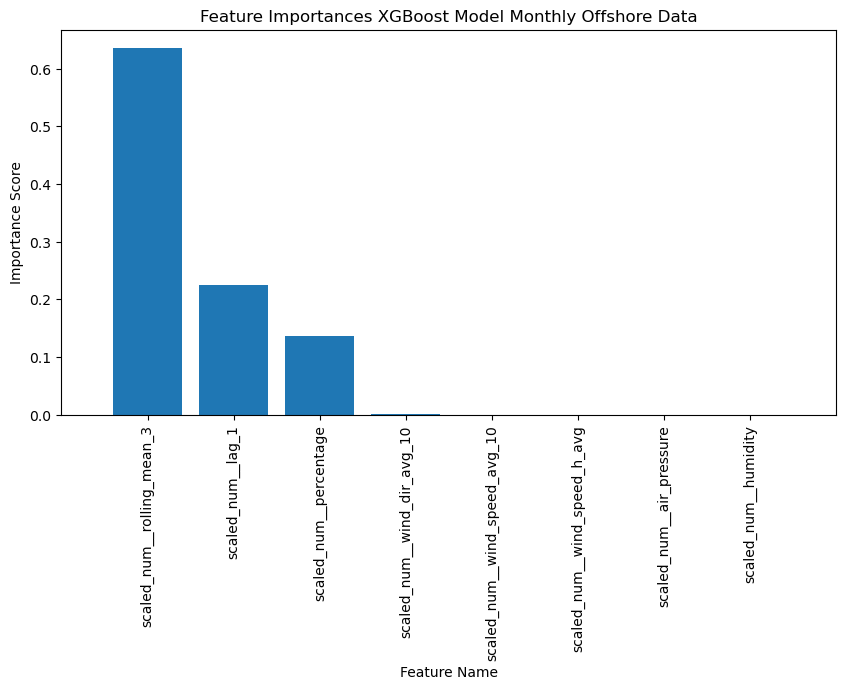

In [97]:
importances = XGB_model_month.feature_importances_

# Hint: We can get feature names from the preprocessor
feature_names = preprocessor.get_feature_names_out()

# Sort feature importances and feature names
indices = np.argsort(importances)[::-1]  # Sort in descending order
sorted_importances = importances[indices]
sorted_feature_names = feature_names[indices]  # Sort feature names accordingly

# Plot feature importances
plt.figure(figsize=(10, 5))
plt.title("Feature Importances XGBoost Model Monthly Offshore Data")
plt.bar(range(len(importances)), sorted_importances, align="center")
plt.xticks(range(len(importances)), sorted_feature_names, rotation=90, fontsize=10)  # Rotate for readability
plt.xlim([-1, len(importances)])
plt.xlabel("Feature Name")
plt.ylabel("Importance Score")
plt.show()

In [44]:
x_axis_train_m = db_monthly["year_mon_day"][:len(y_train_month)]
x_axis_test_m = db_monthly["year_mon_day"][len(y_train_month):]
x_axis_train[0:5]
print(len(x_axis_train_m))
print(len(x_axis_test_m))

90
6


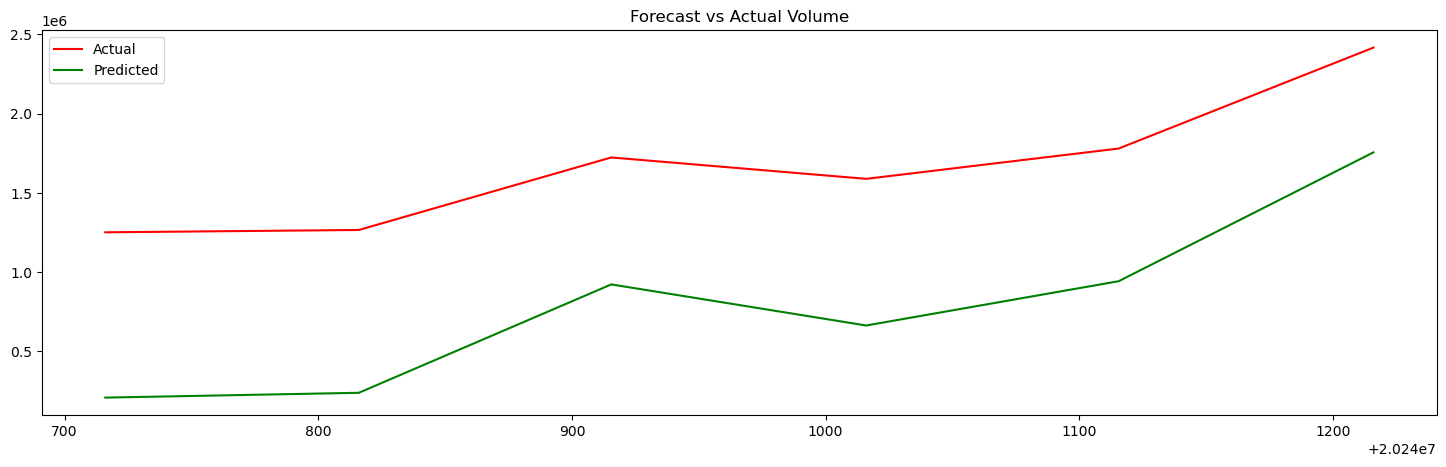

In [267]:
plt.figure(figsize=(18,5))

plt.plot(x_axis_test_m, y_test_month, label="Actual", color='red')
plt.plot(x_axis_test_m, XGB_pred_month, label="Predicted", color='green')
plt.legend()
plt.title("Forecast vs Actual Volume")
plt.show()

In [269]:
param_grid = {
    'max_depth': [5, 7],  
    'min_child_weight': [1, 2, 3],  
    'learning_rate': [0.01, 0.05],  
    'n_estimators': [50, 100, 150],  
    'subsample': [0.75, 0.9],  
    'colsample_bytree': [0.75, 0.9]
}

XGB = XGBRegressor(random_state = 15)
cv_XGB_month_log = GridSearchCV(estimator=XGB, param_grid=param_grid, cv=5) #Here we perform a grid search with 5-fold cross validation
cv_XGB_month_log.fit(X_train_month, y_train_month_log) # Fit the model to the training set - this will perform the grid search and find the model with the best hyper-parameters

# Mean cross-validated score of the best_estimator
print("Mean cross-validated score of the best_estimator:", cv_XGB_month_log.best_score_)

# Print the best parameters
print("Best parameters:", cv_XGB_month_log.best_params_)

# Refit the model with the best parameters on the entire training set
XGB_model_month_log = cv_XGB_month_log.best_estimator_
XGB_pred_month_log = XGB_model_month_log.predict(X_test_month)

#Calculating the accuracy
print("Best XGB Classifier")
print("Test Set MSE: ", mean_squared_error(y_test_month_log, XGB_pred_month_log))


Mean cross-validated score of the best_estimator: 0.8529626002351482
Best parameters: {'colsample_bytree': 0.9, 'learning_rate': 0.05, 'max_depth': 5, 'min_child_weight': 1, 'n_estimators': 150, 'subsample': 0.75}
Best XGB Classifier
Test Set MSE:  1.1380666065077392


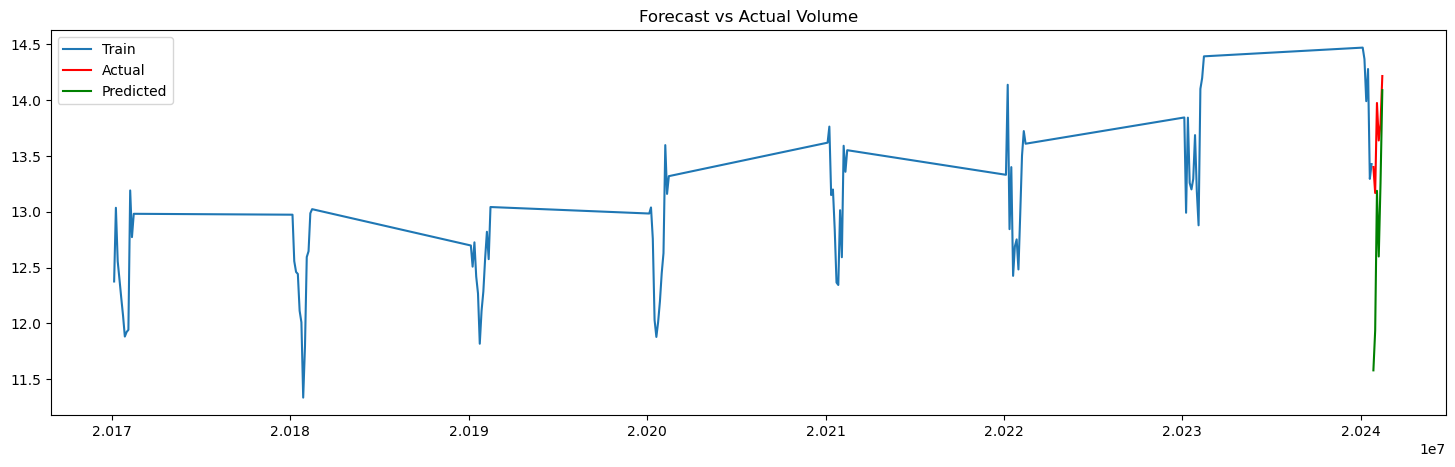

In [271]:
plt.figure(figsize=(18,5))
plt.plot(x_axis_train_m, y_train_month_log, label="Train")
plt.plot(x_axis_test_m, y_test_month_log, label="Actual", color='red')
plt.plot(x_axis_test_m, XGB_pred_month_log, label="Predicted", color='green')
plt.legend()
plt.title("Forecast vs Actual Volume")
plt.show()

# Weekly

In [46]:
# Convert hourly data to weekly data
db_weekly = data.groupby('week_number').mean(numeric_only=True)

X_week = db_weekly.drop(["volume", "capacity",  #capacity & volume are the same
                    "emission", "emissionfactor", "log_volume", "ratio_VC", "max_capacity", 
                           "stationary_volume"], 
                      axis=1)

# our target variable
y_week = db_weekly["volume"]
y_week_log = db_weekly["log_volume"]

# Features
X_train_week = X_week[X_week.index <= 406]
X_test_week = X_week[(X_week.index > 406)]

# Label
y_train_week = y_week[:X_train_week.shape[0]] #list slice: from beginning to end of X-train
y_test_week = y_week[X_train_week.shape[0]:] #list slice: from end of X-train to the end of the data

# Label Log
y_train_week_log = y_week_log[:X_train_week.shape[0]] #list slice: from beginning to end of X-train
y_test_week_log = y_week_log[X_train_week.shape[0]:] #list slice: from end of X-train to the end of the data

In [48]:
print(X_train_week.shape)
print(X_test_week.shape)
print(y_train_week.shape)
print(y_test_week.shape)
print(y_train_week_log.shape)
print(y_test_week_log.shape)

(406, 10)
(12, 10)
(406,)
(12,)
(406,)
(12,)


In [50]:
# subset dataframe to only contain the features we are interested in
numeric_features = ["wind_dir_avg_10", "wind_speed_h_avg", "wind_speed_avg_10", "air_pressure", "humidity", "percentage", "rolling_mean_3", "lag_1"]
X_train_week = X_train_week.loc[:, numeric_features]
X_test_week = X_test_week.loc[:, numeric_features]

# Define the preprocessor
preprocessor = ColumnTransformer([
    ("scaled_num", StandardScaler(), numeric_features)
])


# Transform the data with the scaler
X_train_norm_week = preprocessor.fit_transform(X_train_week)
X_test_norm_week = preprocessor.fit_transform(X_test_week)

In [52]:
#add feature names back 
X_train_week = pd.DataFrame(X_train_norm_week, columns=X_train_week.columns.values, index=X_train_week.index.values)

X_test_week = pd.DataFrame(X_test_norm_week, columns = X_test_week.columns.values, index=X_test_week.index.values)

X_train_week.head()

,wind_dir_avg_10,wind_speed_h_avg,wind_speed_avg_10,air_pressure,humidity,percentage,rolling_mean_3,lag_1
1,0.959893,0.780474,0.781010,1.326430,-0.026382,1.168905,-0.245478,-0.245448
2,1.287998,1.270758,1.272789,-0.661653,0.516703,1.007488,-0.313187,-0.313406
3,-1.001552,-1.976019,-1.977914,2.289382,0.995128,-1.449021,-1.174151,-1.173389
4,-0.369357,-1.243582,-1.238203,1.116265,0.904156,-0.599141,-0.882050,-0.882335
5,-0.969311,-0.351467,-0.363225,-0.763257,1.450244,0.525847,-0.471738,-0.471991


In [54]:
print(X_train_week.shape)
print(X_test_week.shape)
print(y_train_week.shape)
print(y_test_week.shape)
print(y_train_week_log.shape)
print(y_test_week_log.shape)

(406, 8)
(12, 8)
(406,)
(12,)
(406,)
(12,)


In [56]:
param_grid = {
    'max_depth': [5, 7],  
    'min_child_weight': [1, 2, 3],  
    'learning_rate': [0.01, 0.05],  
    'n_estimators': [50, 100, 150],  
    'subsample': [0.75, 0.9],  
    'colsample_bytree': [0.75, 0.9]
}

XGB = XGBRegressor(random_state = 15)
cv_XGB_week = GridSearchCV(estimator=XGB, param_grid=param_grid, cv=5) #Here we perform a grid search with 5-fold cross validation
cv_XGB_week.fit(X_train_week, y_train_week) # Fit the model to the training set - this will perform the grid search and find the model with the best hyper-parameters

# Mean cross-validated score of the best_estimator
print("Mean cross-validated score of the best_estimator:", cv_XGB_week.best_score_)

# Print the best parameters
print("Best parameters:", cv_XGB_week.best_params_)

# Refit the model with the best parameters on the entire training set
XGB_model_week = cv_XGB_week.best_estimator_
XGB_pred_week = XGB_model_week.predict(X_test_week)

#Calculating the accuracy
print("Best XGB Classifier")
print("Test Set MSE: ", mean_squared_error(y_test_week, XGB_pred_week))


Mean cross-validated score of the best_estimator: 0.9697421118286653
Best parameters: {'colsample_bytree': 0.9, 'learning_rate': 0.05, 'max_depth': 5, 'min_child_weight': 1, 'n_estimators': 150, 'subsample': 0.9}
Best XGB Classifier
Test Set MSE:  1452129558811.4377


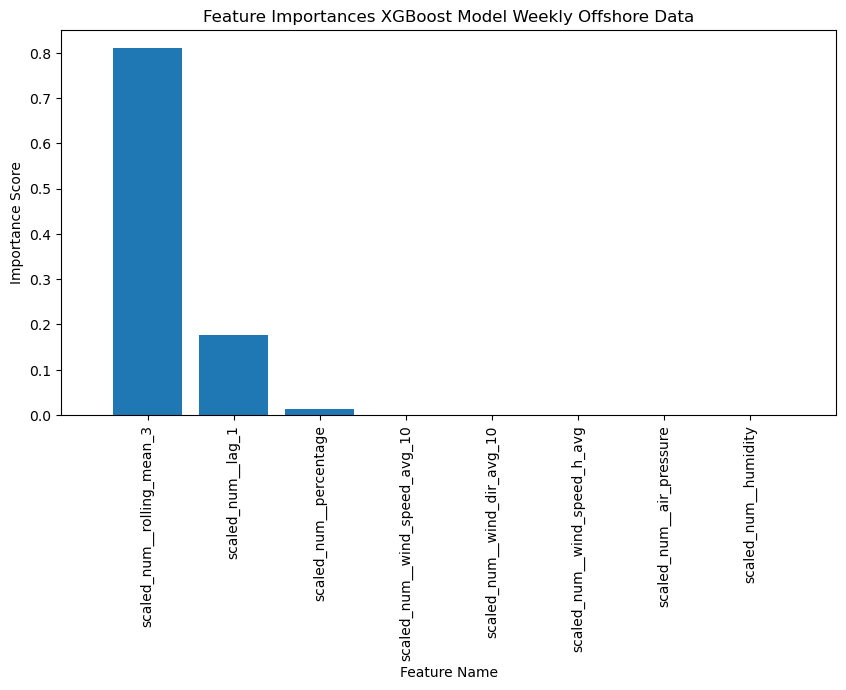

In [101]:
importances = XGB_model_week.feature_importances_

# Hint: We can get feature names from the preprocessor
feature_names = preprocessor.get_feature_names_out()

# Sort feature importances and feature names
indices = np.argsort(importances)[::-1]  # Sort in descending order
sorted_importances = importances[indices]
sorted_feature_names = feature_names[indices]  # Sort feature names accordingly

# Plot feature importances
plt.figure(figsize=(10, 5))
plt.title("Feature Importances XGBoost Model Weekly Offshore Data")
plt.bar(range(len(importances)), sorted_importances, align="center")
plt.xticks(range(len(importances)), sorted_feature_names, rotation=90, fontsize=10)  # Rotate for readability
plt.xlim([-1, len(importances)])
plt.xlabel("Feature Name")
plt.ylabel("Importance Score")
plt.show()

In [289]:
x_axis_train_w = db_weekly["year_mon_day"][:len(y_train_week)]
x_axis_test_w = db_weekly["year_mon_day"][len(y_train_week):]
print(len(x_axis_train_w))
print(len(x_axis_test_w))

406
12


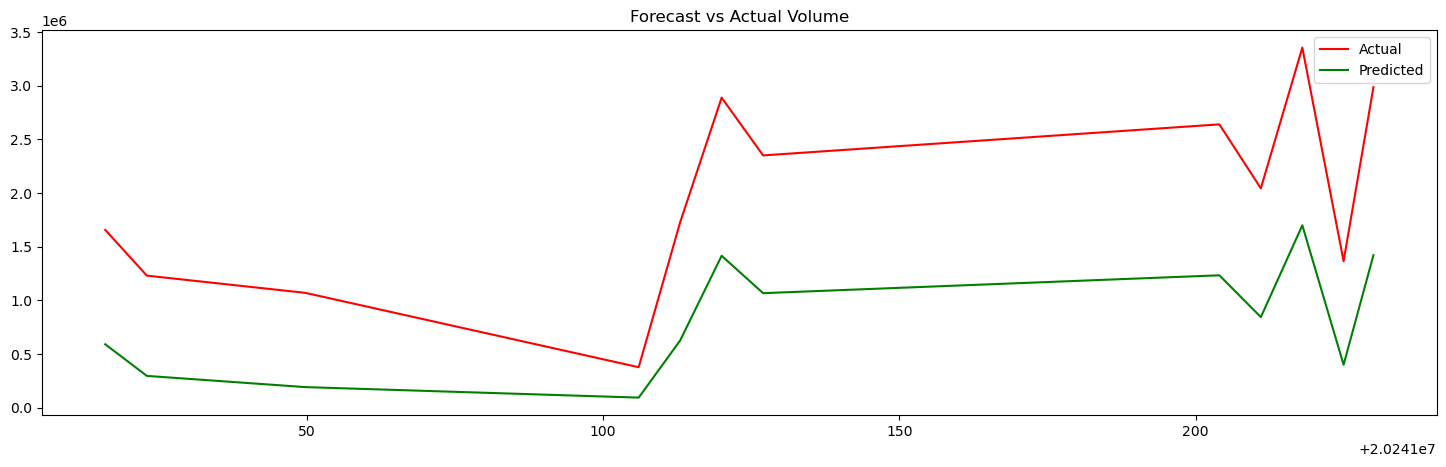

In [293]:
plt.figure(figsize=(18,5))
plt.plot(x_axis_test_w, y_test_week, label="Actual", color='red')
plt.plot(x_axis_test_w, XGB_pred_week, label="Predicted", color='green')
plt.legend()
plt.title("Forecast vs Actual Volume")
plt.show()

In [295]:
param_grid = {
    'max_depth': [5, 7],  
    'min_child_weight': [1, 2, 3],  
    'learning_rate': [0.01, 0.05],  
    'n_estimators': [50, 100, 150],  
    'subsample': [0.75, 0.9],  
    'colsample_bytree': [0.75, 0.9]
}

XGB = XGBRegressor(random_state = 15)
cv_XGB_week_log = GridSearchCV(estimator=XGB, param_grid=param_grid, cv=5) #Here we perform a grid search with 5-fold cross validation
cv_XGB_week_log.fit(X_train_week, y_train_week_log) # Fit the model to the training set - this will perform the grid search and find the model with the best hyper-parameters

# Mean cross-validated score of the best_estimator
print("Mean cross-validated score of the best_estimator:", cv_XGB_week_log.best_score_)

# Print the best parameters
print("Best parameters:", cv_XGB_week_log.best_params_)

# Refit the model with the best parameters on the entire training set
XGB_model_week_log = cv_XGB_week_log.best_estimator_
XGB_pred_week_log = XGB_model_week_log.predict(X_test_week)

#Calculating the accuracy
print("Best XGB Classifier")
print("Test Set MSE: ", mean_squared_error(y_test_week_log, XGB_pred_week_log))


Mean cross-validated score of the best_estimator: 0.9061890209258981
Best parameters: {'colsample_bytree': 0.9, 'learning_rate': 0.05, 'max_depth': 5, 'min_child_weight': 2, 'n_estimators': 100, 'subsample': 0.75}
Best XGB Classifier
Test Set MSE:  1.0084521127831236


/Users/fmtetteroo/opt/anaconda3/lib/python3.12/site-packages/numpy/ma/core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


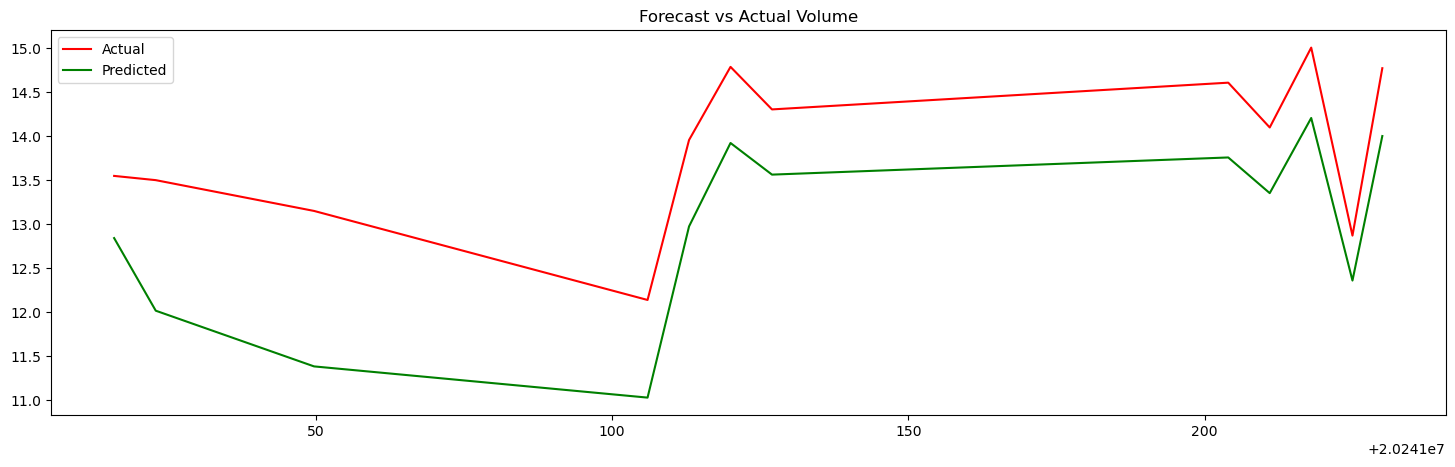

In [297]:
plt.figure(figsize=(18,5))
plt.plot(x_axis_test_w, y_test_week_log, label="Actual", color='red')
plt.plot(x_axis_test_w, XGB_pred_week_log, label="Predicted", color='green')
plt.legend()
plt.title("Forecast vs Actual Volume")
plt.show()

# Daily

In [58]:
data['date2'] = pd.to_datetime(data['date'], format='ISO8601')
db_daily = data.groupby('date2').mean(numeric_only=True)
# Split into train and test set
db_daily.index = pd.to_datetime(db_daily.index)

X_day = db_daily.drop(["volume", "capacity",  #capacity & volume are the same
                    "emission", "emissionfactor", "log_volume", "ratio_VC", "max_capacity", "stationary_volume"], #are always 0 and can be ignored
                      axis=1)

#our targer variable
y_day = db_daily["volume"]
y_day_log = db_daily["log_volume"]

# Features
X_train_day = X_day[X_day.index <= '2024-11-01']
X_test_day = X_day[X_day.index > '2024-11-01']

# Label
y_train_day = y_day[:X_train_day.shape[0]] #list slice: from beginning to end of X-train
y_test_day = y_day[X_train_day.shape[0]:] #list slice: from end of X-train to the end of the data

# Label log
y_train_day_log = y_day_log[:X_train_day.shape[0]] #list slice: from beginning to end of X-train
y_test_day_log = y_day_log[X_train_day.shape[0]:] #list slice: from end of X-train to the end of the data


/var/folders/19/l03rx7hx7313wlqw4t3dy1wm0000gn/T/ipykernel_97439/997300015.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['date2'] = pd.to_datetime(data['date'], format='ISO8601')


In [60]:
print(X_train_day.shape)
print(X_test_day.shape)
print(y_train_day.shape)
print(y_test_day.shape)
print(y_train_day_log.shape)
print(y_test_day_log.shape)

(2862, 11)
(60, 11)
(2862,)
(60,)
(2862,)
(60,)


In [62]:
# subset dataframe to only contain the features we are interested in
numeric_features = ["wind_dir_avg_10", "wind_speed_h_avg", "wind_speed_avg_10", "air_pressure", "humidity", "percentage", "rolling_mean_3", "lag_1"]
X_train_day = X_train_day.loc[:, numeric_features]
X_test_day = X_test_day.loc[:, numeric_features]

# Define the preprocessor
preprocessor = ColumnTransformer([
    ("scaled_num", StandardScaler(), numeric_features)
])

# Transform the data with the scaler
X_train_norm_day = preprocessor.fit_transform(X_train_day)
X_test_norm_day = preprocessor.fit_transform(X_test_day)

In [64]:
#add feature names back 
X_train_day = pd.DataFrame(X_train_norm_day, columns=X_train_day.columns.values, index=X_train_day.index.values)
X_test_day = pd.DataFrame(X_test_norm_day, columns = X_test_day.columns.values, index=X_test_day.index.values)
X_train_day.head()

,wind_dir_avg_10,wind_speed_h_avg,wind_speed_avg_10,air_pressure,humidity,percentage,rolling_mean_3,lag_1
2017-01-01,0.504635,0.531850,0.487005,0.186949,1.475317,0.928814,-0.155400,-0.156665
2017-01-02,1.793325,0.238455,0.261307,0.785036,-0.779581,1.204230,-0.056539,-0.054581
2017-01-03,1.065553,1.145252,1.178920,0.489870,0.370594,1.537071,0.059426,0.058903
2017-01-04,1.787011,1.980410,1.969344,0.196092,-1.046410,1.625917,0.111564,0.113025
2017-01-05,-1.235747,-0.353700,-0.372650,1.769222,-0.969872,-0.252036,-0.586883,-0.588390


In [66]:
print(X_train_day.shape)
print(X_test_day.shape)
print(y_train_day.shape)
print(y_test_day.shape)
print(y_train_day_log.shape)
print(y_test_day_log.shape)

(2862, 8)
(60, 8)
(2862,)
(60,)
(2862,)
(60,)


In [68]:
param_grid = {
    'max_depth': [5, 7],  
    'min_child_weight': [1, 2, 3],  
    'learning_rate': [0.01, 0.05],  
    'n_estimators': [50, 100, 150],  
    'subsample': [0.75, 0.9],  
    'colsample_bytree': [0.75, 0.9]
}

XGB = XGBRegressor(random_state = 15)
cv_XGB_day = GridSearchCV(estimator=XGB, param_grid=param_grid, cv=5) #Here we perform a grid search with 5-fold cross validation
cv_XGB_day.fit(X_train_day, y_train_day) # Fit the model to the training set - this will perform the grid search and find the model with the best hyper-parameters

# Mean cross-validated score of the best_estimator
print("Mean cross-validated score of the best_estimator:", cv_XGB_day.best_score_)

# Print the best parameters
print("Best parameters:", cv_XGB_day.best_params_)

# Refit the model with the best parameters on the entire training set
XGB_model_day = cv_XGB_day.best_estimator_
XGB_pred_day = XGB_model_day.predict(X_test_day)

#Calculating the accuracy
print("Best XGB Classifier")
print("Test Set MSE: ", mean_squared_error(y_test_day, XGB_pred_day))

/Users/fmtetteroo/opt/anaconda3/lib/python3.12/site-packages/numpy/ma/core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Mean cross-validated score of the best_estimator: 0.9687821598250043
Best parameters: {'colsample_bytree': 0.9, 'learning_rate': 0.05, 'max_depth': 7, 'min_child_weight': 1, 'n_estimators': 150, 'subsample': 0.9}
Best XGB Classifier
Test Set MSE:  1872218479937.1484


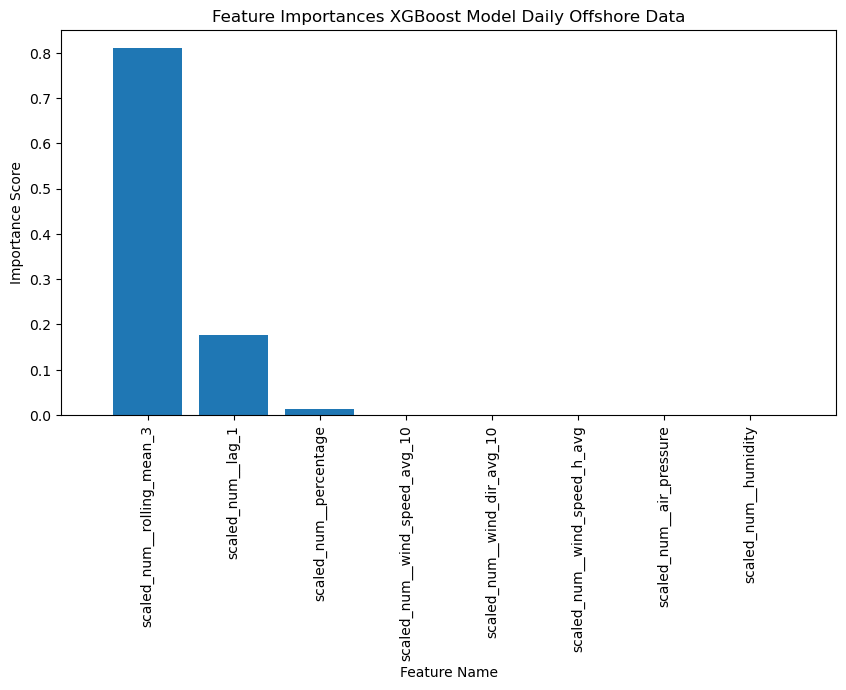

In [105]:
importances = XGB_model_week.feature_importances_

# Hint: We can get feature names from the preprocessor
feature_names = preprocessor.get_feature_names_out()

# Sort feature importances and feature names
indices = np.argsort(importances)[::-1]  # Sort in descending order
sorted_importances = importances[indices]
sorted_feature_names = feature_names[indices]  # Sort feature names accordingly

# Plot feature importances
plt.figure(figsize=(10, 5))
plt.title("Feature Importances XGBoost Model Daily Offshore Data")
plt.bar(range(len(importances)), sorted_importances, align="center")
plt.xticks(range(len(importances)), sorted_feature_names, rotation=90, fontsize=10)  # Rotate for readability
plt.xlim([-1, len(importances)])
plt.xlabel("Feature Name")
plt.ylabel("Importance Score")
plt.show()


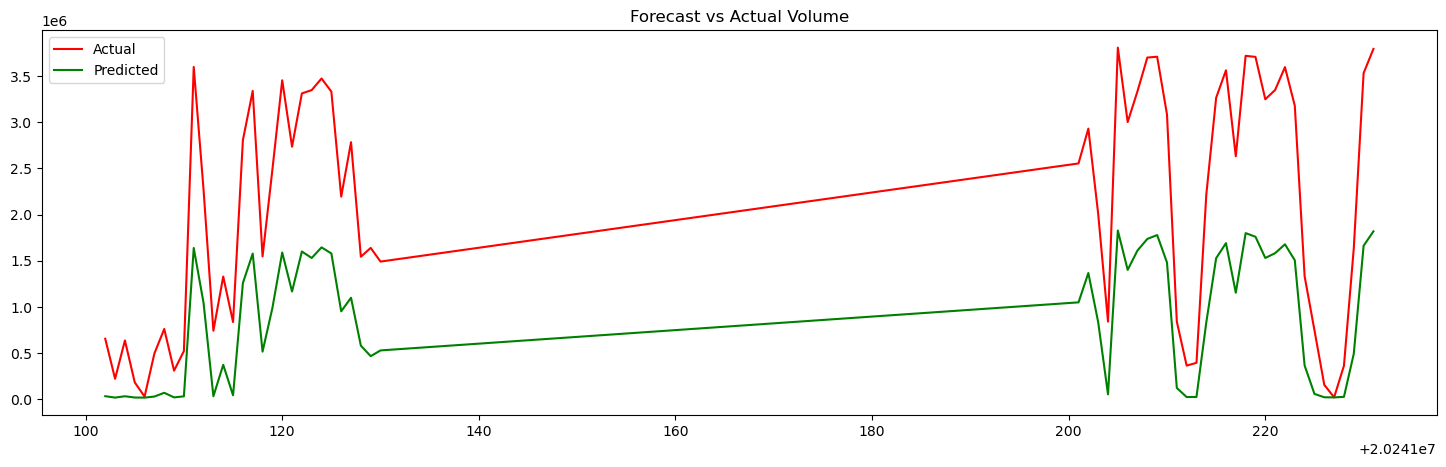

In [313]:
x_axis_train_d = db_daily["year_mon_day"][:len(y_train_day)]
x_axis_test_d = db_daily["year_mon_day"][len(y_train_day):]
print(len(x_axis_train_d))
print(len(x_axis_test_d))

plt.figure(figsize=(18,5))
plt.plot(x_axis_test_d, y_test_day, label="Actual", color='red')
plt.plot(x_axis_test_d, XGB_pred_day, label="Predicted", color='green')
plt.legend()
plt.title("Forecast vs Actual Volume")
plt.show()

In [315]:
param_grid = {
    'max_depth': [5, 7],  
    'min_child_weight': [1, 2, 3],  
    'learning_rate': [0.01, 0.05],  
    'n_estimators': [50, 100, 150],  
    'subsample': [0.75, 0.9],  
    'colsample_bytree': [0.75, 0.9]
}

XGB = XGBRegressor(random_state = 15)
cv_XGB_day_log = GridSearchCV(estimator=XGB, param_grid=param_grid, cv=5) #Here we perform a grid search with 5-fold cross validation
cv_XGB_day_log.fit(X_train_day, y_train_day_log) # Fit the model to the training set - this will perform the grid search and find the model with the best hyper-parameters

# Mean cross-validated score of the best_estimator
print("Mean cross-validated score of the best_estimator:", cv_XGB_day_log.best_score_)

# Print the best parameters
print("Best parameters:", cv_XGB_day_log.best_params_)

# Refit the model with the best parameters on the entire training set
XGB_model_day_log = cv_XGB_day_log.best_estimator_
XGB_pred_day_log = XGB_model_day_log.predict(X_test_day)

#Calculating the accuracy
print("Best XGB Classifier")
print("Test Set MSE: ", mean_squared_error(y_test_day_log, XGB_pred_day_log))

Mean cross-validated score of the best_estimator: 0.9531147262549139
Best parameters: {'colsample_bytree': 0.9, 'learning_rate': 0.05, 'max_depth': 5, 'min_child_weight': 3, 'n_estimators': 100, 'subsample': 0.75}
Best XGB Classifier
Test Set MSE:  3.3722826331495095


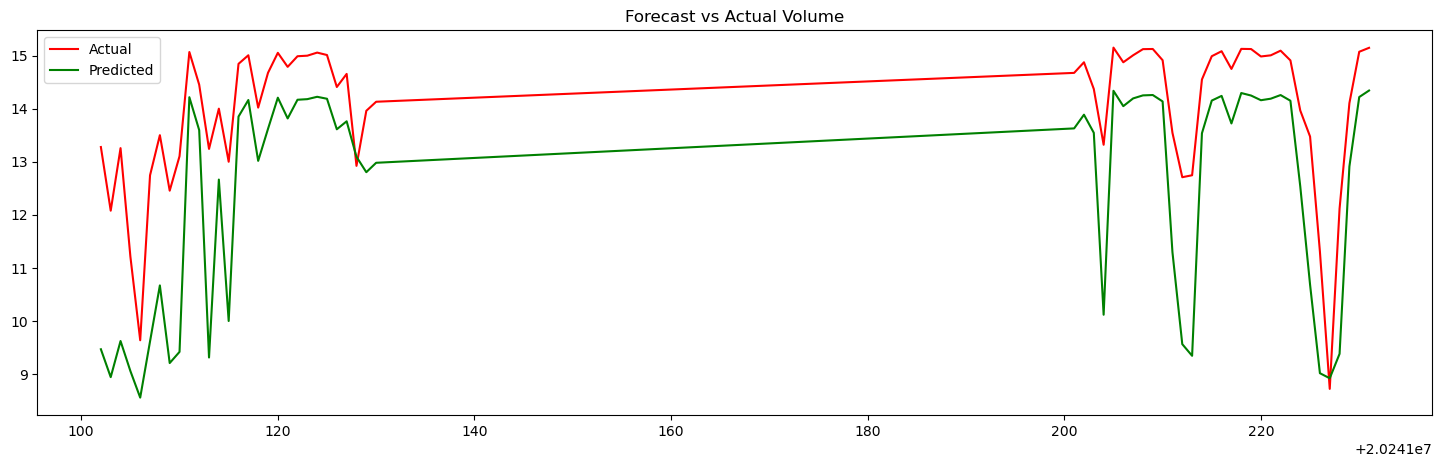

In [317]:
plt.figure(figsize=(18,5))
plt.plot(x_axis_test_d, y_test_day_log, label="Actual", color='red')
plt.plot(x_axis_test_d, XGB_pred_day_log, label="Predicted", color='green')
plt.legend()
plt.title("Forecast vs Actual Volume")
plt.show()

# Creating the official graphs for the report Monthly/Weekly/Daily

In [73]:
from sktime.forecasting.model_selection import temporal_train_test_split
off_df = pd.read_csv("final_offshore_data_2017_2025.csv", dtype = {'year_mon_day':'int32'})
# Removing data from 2025
off_df = off_df[off_df['full_datetime'] < "2025-01-01-01"]
# Convert 'correct days' to datetype format for further processing
off_df[['date', 'hour']] = off_df['correct_days'].str.rsplit('-', n=1, expand=True)
off_df['hour'] = off_df['hour'].astype(int) - 1
off_df['datetime'] = pd.to_datetime(off_df['date']) + pd.to_timedelta(off_df['hour'], unit='h')
off_df = off_df.drop(['year_mon_day', 'hour', 'full_datetime', 'capacity', 'emission', 'emissionfactor', 'percentage', 'date', 'correct_days', "wind_speed_h_avg"], axis = 1)
# Set datetime as index
off_df = off_df.set_index('datetime')

# Monthly averages
off_df_m = off_df.resample('M').mean()
# Split data into target and exogenous variables
y_m = off_df_m['volume']
X_m = off_df_m.drop('volume', axis=1)  # All exogenous variables
# Create train/test split
y_train_off_m, y_test_off_m, X_train_off_m, X_test_off_m = temporal_train_test_split(y_m, X_m, test_size=0.0625)

# Weekly averages
off_df_w = off_df.resample('W').mean()
# Remove last row for 2025-01-05
off_df_w = off_df_w.iloc[:-1]
# Split data into target and exogenous variables
y_w = off_df_w['volume']
X_w = off_df_w.drop('volume', axis=1)  # All exogenous variables
# Create train/test split
y_train_off_w, y_test_off_w, X_train_off_w, X_test_off_w = temporal_train_test_split(y_w, X_w, test_size=0.0287)

# Daily averages
off_df_d = off_df.resample('D').mean()
# Split data into target and exogenous variables
y_d = off_df_d['volume']
X_d = off_df_d.drop('volume', axis=1)  # All exogenous variables
# Create train/test split
y_train_off_d, y_test_off_d, X_train_off_d, X_test_off_d = temporal_train_test_split(y_d, X_d, test_size=0.02053)

# Onshore
on_df = pd.read_csv("final_onshore_data_2017_2025.csv", dtype = {'year_mon_day':'int32'})
# Removing data from 2025
on_df = on_df[on_df['full_datetime'] < "2025-01-01-01"]
# Convert 'correct days' to datetype format for further processing
on_df[['date', 'hour']] = on_df['correct_days'].str.rsplit('-', n=1, expand=True)
on_df['hour'] = on_df['hour'].astype(int) - 1
on_df['datetime'] = pd.to_datetime(on_df['date']) + pd.to_timedelta(on_df['hour'], unit='h')
on_df = on_df.drop(['year_mon_day', 'hour', 'full_datetime', 'capacity', 'emission', 'emissionfactor', 'percentage', 'date', 'correct_days', "wind_speed_h_avg"], axis = 1)
# Set datetime as index
on_df = on_df.set_index('datetime')

# Monthly averages
on_df_m = on_df.resample('M').mean()
# Split data into target and exogenous variables
y_m = on_df_m['volume']
X_m = on_df_m.drop('volume', axis=1)  # All exogenous variables
# Create train/test split
y_train_on_m, y_test_on_m, X_train_on_m, X_test_on_m = temporal_train_test_split(y_m, X_m, test_size=0.0625)

# Weekly averages
on_df_w = on_df.resample('W').mean()
# Remove last row for 2025-01-05
on_df_w = on_df_w.iloc[:-1]
# Split data into target and exogenous variables
y_w = on_df_w['volume']
X_w = on_df_w.drop('volume', axis=1)  # All exogenous variables
# Create train/test split
y_train_on_w, y_test_on_w, X_train_on_w, X_test_on_w = temporal_train_test_split(y_w, X_w, test_size=0.0287)

# Daily averages
on_df_d = on_df.resample('D').mean()
# Split data into target and exogenous variables
y_d = on_df_d['volume']
X_d = on_df_d.drop('volume', axis=1)  # All exogenous variables
# Create train/test split
y_train_on_d, y_test_on_d, X_train_on_d, X_test_on_d = temporal_train_test_split(y_d, X_d, test_size=0.02053)

/var/folders/19/l03rx7hx7313wlqw4t3dy1wm0000gn/T/ipykernel_97439/2821455781.py:14: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  off_df_m = off_df.resample('M').mean()
/var/folders/19/l03rx7hx7313wlqw4t3dy1wm0000gn/T/ipykernel_97439/2821455781.py:52: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  on_df_m = on_df.resample('M').mean()


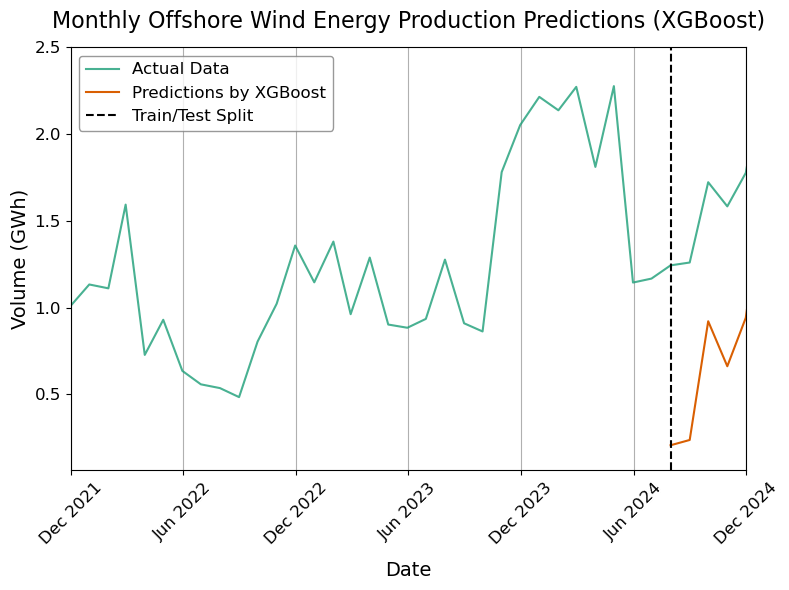

In [83]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter

# Function to convert to millions
def millions(x, pos):
    return f'{x * 1e-6:.1f}'

# ===== Monthly - Offshore =====
plt.figure(figsize=(8, 6))
plt.plot(pd.to_datetime(off_df_m.index), off_df_m['volume'], label='Actual Data', color='#1b9e77', alpha = 0.8)
plt.plot(pd.to_datetime(y_test_off_m.index), XGB_pred_month, label='Predictions by XGBoost', color='#d95f02')
split_date = pd.to_datetime(y_test_off_m.index[0], format = '%Y-%m-%d')
plt.axvline(x=split_date, color='k', linestyle='--', label='Train/Test Split')
plt.title('Monthly Offshore Wind Energy Production Predictions (XGBoost)', pad = 14, size = 16)
plt.xlabel('Date', labelpad=10, size=14)
plt.gca().yaxis.set_major_formatter(FuncFormatter(millions))
plt.ylabel('Volume (GWh)', size=14)
plt.grid(axis = 'x')
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xlim(pd.to_datetime('2021-12'), pd.to_datetime('2024-12')) 
plt.ylim(top=2_500_000)
plt.tick_params(axis='both', labelsize=12)
plt.tight_layout()
plt.legend(loc='best', fontsize=12, frameon=True, facecolor='white', edgecolor='grey', fancybox=True, framealpha = 0.8)
#plt.savefig('plots/off_m.png', dpi=300, bbox_inches='tight')
plt.show()

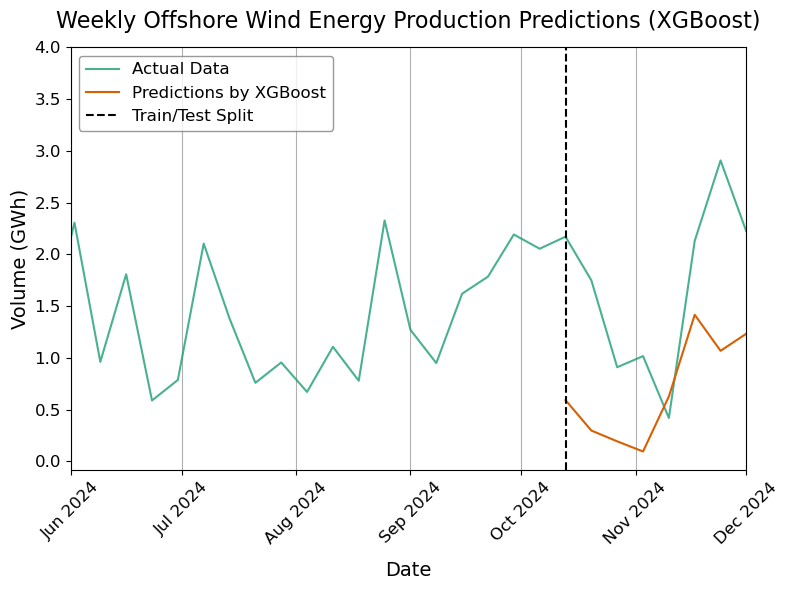

In [85]:
# ===== Weekly - Offshore =====
plt.figure(figsize=(8, 6))
plt.plot(pd.to_datetime(off_df_w.index), off_df_w['volume'], label='Actual Data', color='#1b9e77', alpha = 0.8)
plt.plot(pd.to_datetime(y_test_off_w.index), XGB_pred_week, label='Predictions by XGBoost', color='#d95f02')
split_date = pd.to_datetime(y_test_off_w.index[0], format = '%Y-%m-%d')
plt.axvline(x=split_date, color='k', linestyle='--', label='Train/Test Split')
plt.title('Weekly Offshore Wind Energy Production Predictions (XGBoost)', pad = 14, size = 16)
plt.xlabel('Date', labelpad=10, size=14)
plt.gca().yaxis.set_major_formatter(FuncFormatter(millions))
plt.ylabel('Volume (GWh)', size=14)
plt.grid(axis = 'x')
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xlim(pd.to_datetime('2024-06'), pd.to_datetime('2024-12')) 
plt.ylim(top=4_000_000)
plt.tick_params(axis='both', labelsize=12)
plt.tight_layout()
plt.legend(loc='best', fontsize=12, frameon=True, facecolor='white', edgecolor='grey', fancybox=True, framealpha = 0.8)
#plt.savefig('plots/off_w.png', dpi=300, bbox_inches='tight')
plt.show()

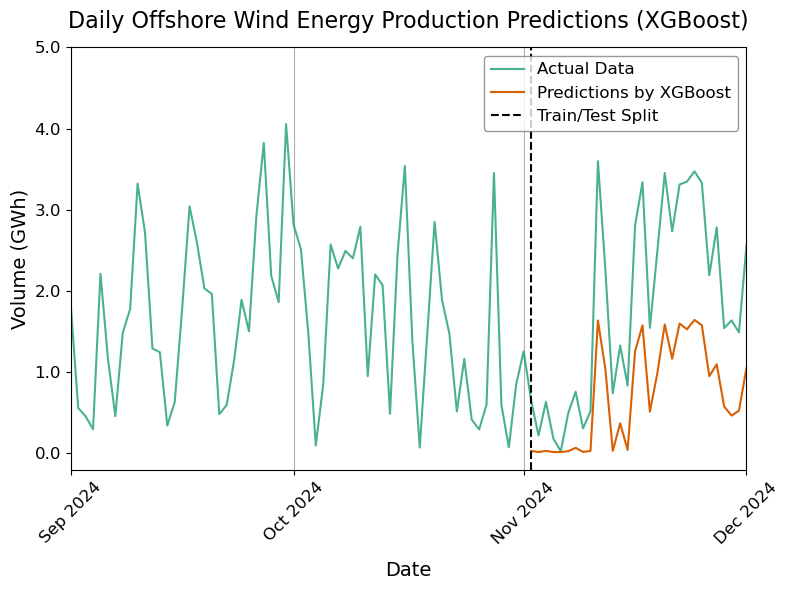

In [89]:
# ===== Daily - Offshore =====
plt.figure(figsize=(8, 6))
plt.plot(pd.to_datetime(off_df_d.index), off_df_d['volume'], label='Actual Data', color='#1b9e77', alpha = 0.8)
plt.plot(pd.to_datetime(y_test_off_d.index), XGB_pred_day, label='Predictions by XGBoost', color='#d95f02')
split_date = pd.to_datetime(y_test_off_d.index[0], format = '%Y-%m-%d')
plt.axvline(x=split_date, color='k', linestyle='--', label='Train/Test Split')
plt.title('Daily Offshore Wind Energy Production Predictions (XGBoost)', pad = 14, size = 16)
plt.xlabel('Date', labelpad=10, size=14)
plt.gca().yaxis.set_major_formatter(FuncFormatter(millions))
plt.ylabel('Volume (GWh)', size=14)
plt.grid(axis = 'x')
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xlim(pd.to_datetime('2024-09'), pd.to_datetime('2024-12')) 
plt.ylim(top=5_000_000)
plt.tick_params(axis='both', labelsize=12)
plt.tight_layout()
plt.legend(loc='best', fontsize=12, frameon=True, facecolor='white', edgecolor='grey', fancybox=True, framealpha = 0.8)
#plt.savefig('plots/off_d.png', dpi=300, bbox_inches='tight')
plt.show()